In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image
from google.colab import files

In [ ]:
class ImageTransformations:
    def __init__(self, image_path):
        """Initialize with image path"""
        self.image_path = image_path
        self.img_pil = Image.open(image_path)
        self.img_cv = cv2.imread(image_path)
        self.rows, self.cols = self.img_cv.shape[:2]

        # 3x3 identity matrix for affine accumulation
        self.matrix = np.eye(3)

    def translate(self, tx=50, ty=30):
        """TRANSLATION: Shift image using padding/cropping"""
        width, height = self.img_pil.size

        # PIL Translation - Create larger canvas with white background
        new_img = Image.new("RGB", (width + abs(tx)*2, height + abs(ty)*2), (255, 255, 255))
        new_img.paste(self.img_pil, (abs(tx), abs(ty)))
        translated_pil = new_img.crop((tx, ty, tx+width, ty+height))

        # OpenCV Translation - Add padding then crop
        rows, cols = self.img_cv.shape[:2]
        pad_top, pad_bottom = max(ty, 0), max(-ty, 0)
        pad_left, pad_right = max(tx, 0), max(-tx, 0)
        padded = cv2.copyMakeBorder(self.img_cv, pad_top, pad_bottom,
                                   pad_left, pad_right, cv2.BORDER_CONSTANT, value=[255,255,255])
        translated_cv = padded[pad_top:pad_top+rows, pad_left:pad_left+cols]

        return translated_pil, translated_cv

    def rotate(self, angle=45):
        """ROTATION: Using built-in rotate methods"""
        # PIL rotation with automatic canvas expansion
        rotated_pil = self.img_pil.rotate(angle, expand=True)

        # OpenCV rotation around center
        h, w = self.img_cv.shape[:2]
        center = (w//2, h//2)
        rot_mat = cv2.getRotationMatrix2D(center, angle, 1.0)
        rotated_cv = cv2.warpAffine(self.img_cv, rot_mat, (w, h))

        return rotated_pil, rotated_cv

    def scale(self, scale_x=1.5, scale_y=0.8):
        """SCALING: Using built-in resize methods"""
        # PIL resize with Lanczos interpolation (high quality)
        w, h = self.img_pil.size
        scaled_pil = self.img_pil.resize((int(w*scale_x), int(h*scale_y)), Image.LANCZOS)

        # OpenCV resize (note: OpenCV uses height,width order)
        h_cv, w_cv = self.img_cv.shape[:2]
        scaled_cv = cv2.resize(self.img_cv, (int(w_cv*scale_x), int(h_cv*scale_y)),
                              interpolation=cv2.INTER_LANCZOS4)

        return scaled_pil, scaled_cv

    def shear(self, shear_x=0.3, shear_y=0.2):
        """SHEAR: Pixel coordinate remapping (no matrix multiplication)"""
        # Convert PIL to numpy array for pixel manipulation
        img_array = np.array(self.img_pil)
        h, w = img_array.shape[:2]

        # Create coordinate grid for every pixel
        x_indices = np.arange(w)  # 0 to width-1
        y_indices = np.arange(h)  # 0 to height-1
        X, Y = np.meshgrid(x_indices, y_indices)  # 2D maps of all coordinates

        # Apply shear transformation to coordinates
        # Horizontal shear: x' = x + shear_x * y
        # Vertical shear: y' = y + shear_y * x
        shear_map_x = np.clip(X + shear_x * Y, 0, w-1).astype(np.int32)
        shear_map_y = np.clip(Y + shear_y * X, 0, h-1).astype(np.int32)

        # Remap pixels using new coordinates
        sheared = img_array[shear_map_y, shear_map_x]
        return Image.fromarray(sheared)

    def point_scale(self, scale_x=2, scale_y=2):
      """
      POINT BASED SCALING (Nearest Neighbor)
      Works for both Upscale and Downscale
      """

      img_array = np.array(self.img_pil)
      h, w = img_array.shape[:2]

      new_h = int(h * scale_y)
      new_w = int(w * scale_x)

      scaled = np.zeros((new_h, new_w, 3), dtype=np.uint8)

      for y in range(new_h):
          for x in range(new_w):

              # Map output pixel back to input pixel
              orig_x = int(x / scale_x)
              orig_y = int(y / scale_y)

              scaled[y, x] = img_array[orig_y, orig_x]

      return Image.fromarray(scaled)

    def mean_filter(self, kernel_size=3):
        """
        MEAN FILTER (Average Filter)
        Smooths image using neighborhood averaging
        """
        filtered = cv2.blur(self.img_cv, (kernel_size, kernel_size))
        return Image.fromarray(cv2.cvtColor(filtered, cv2.COLOR_BGR2RGB))

    def median_filter(self, kernel_size=3):
        """
        MEDIAN FILTER
        Removes salt-and-pepper noise
        """
        filtered = cv2.medianBlur(self.img_cv, kernel_size)
        return Image.fromarray(cv2.cvtColor(filtered, cv2.COLOR_BGR2RGB))

    def add_rotation(self, angle):
        """Add rotation to affine matrix"""
        center = (self.cols // 2, self.rows // 2)

        rot = cv2.getRotationMatrix2D(center, angle, 1)
        rot = np.vstack([rot, [0,0,1]])

        self.matrix = rot @ self.matrix


    def add_scaling(self, sx, sy):
        """Add scaling to affine matrix"""

        scale = np.array([
            [sx,0,0],
            [0,sy,0],
            [0,0,1]
        ])

        self.matrix = scale @ self.matrix


    def add_shearing(self, shx, shy):
        """Add shear transformation"""

        shear = np.array([
            [1,shx,0],
            [shy,1,0],
            [0,0,1]
        ])

        self.matrix = shear @ self.matrix


    def add_translation(self, tx, ty):
        """Add translation transformation"""

        trans = np.array([
            [1,0,tx],
            [0,1,ty],
            [0,0,1]
        ])

        self.matrix = trans @ self.matrix


    def apply_affine(self):
        """Apply accumulated affine transformation"""

        final_matrix = self.matrix[:2, :]

        result = cv2.warpAffine(
            self.img_cv,
            final_matrix,
            (self.cols, self.rows)
        )

        return Image.fromarray(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))


    def get_affine(self, choices):
        """Apply transformation based on menu choice"""
        for choice in choices:

            if choice == 1:
                angle = float(input("Enter rotation angle: "))
                self.add_rotation(angle)

            elif choice == 2:
                sx = float(input("Enter scale x: "))
                sy = float(input("Enter scale y: "))
                self.add_scaling(sx, sy)

            elif choice == 3:
                shx = float(input("Enter shear x: "))
                shy = float(input("Enter shear y: "))
                self.add_shearing(shx, shy)

            elif choice == 4:
                tx = float(input("Enter translate x: "))
                ty = float(input("Enter translate y: "))
                self.add_translation(tx, ty)

        return "Combined Affine Transformation", self.apply_affine()


    def Affine_menu(self):
        """Interactive affine transformation menu"""
        while True:

            print("\n" + "="*50)
            print("🎯 AFFINE TRANSFORMATIONS MENU")
            print("="*50)
            print("1. Rotation")
            print("2. Scaling")
            print("3. Shearing")
            print("4. Translation")
            print("0. Exit")
            print("-"*50)

            try:

                choice_input = input(
                    "Enter transformation numbers separated by comma (example: 1,3,4): "
                )

                if choice_input == "0":
                    print("👋 Exiting...")
                    break

                choices = [int(x.strip()) for x in choice_input.split(",")]

                name, result_img = self.get_affine(choices)

                plt.figure(figsize=(8,6))
                plt.imshow(result_img)
                plt.title(name, fontsize=16, fontweight="bold")
                plt.axis("off")
                plt.tight_layout()
                plt.show()

            except ValueError:
                print("❌ Please enter valid numbers!")

            except KeyboardInterrupt:
                print("\n👋 Exiting...")
                break

    def get_transformation(self, choice):
        """Get single transformation based on user input (1=Translation, 2=Rotation, 3=Scaling, 4=Shear)"""
        if choice == 1:
            tx = float(input("Enter translate x: "))
            ty = float(input("Enter translate y: "))
            translated_pil, _ = self.translate(tx,ty)
            return 'Translation', translated_pil
        elif choice == 2:
            angle = float(input("Enter rotation angle: "))
            rotated_pil, _ = self.rotate(angle)
            return 'Rotation', rotated_pil
        elif choice == 3:
            sx = float(input("Enter scale x: "))
            sy = float(input("Enter scale y: "))
            scaled_pil, _ = self.scale(sx,sy)
            return 'Scaling', scaled_pil
        elif choice == 4:
            shx = float(input("Enter shear x: "))
            shy = float(input("Enter shear y: "))
            return 'Shear', self.shear(shx,shy)
        else:
            return 'Invalid choice', self.img_pil

    def Geometric_menu(self):
        """Interactive menu with user input"""
        while True:
            print("\n" + "="*50)
            print("🎯 GEOMETRIC TRANSFORMATIONS MENU")
            print("="*50)
            print("1. Translation (Shift)")
            print("2. Rotation")
            print("3. Scaling")
            print("4. Shearing")
            print("0. Exit")
            print("-"*50)

            try:
                choice = int(input("Enter your choice (0-4): "))

                if choice == 0:
                    print("👋 Exiting...")
                    break

                name, result_img = self.get_transformation(choice)

                if name != 'Invalid choice':
                    # Display result
                    plt.figure(figsize=(8, 6))
                    plt.imshow(result_img)
                    plt.title(f'{name} Transformation', fontsize=16, fontweight='bold')
                    plt.axis('off')
                    plt.tight_layout()
                    plt.show()
                else:
                    print("❌ Invalid choice! Please select 1-4.")

            except ValueError:
                print("❌ Please enter a valid number!")
            except KeyboardInterrupt:
                print("\n👋 Exiting...")
                break

    def get_filter(self, choice):
        """Apply selected filter"""
        if choice == 1:
            k = int(input("Enter the scale factor: "))
            return "Point Filter", self.point_scale(k,k)

        elif choice == 2:
            k = int(input("Enter kernel size (odd number): "))
            return "Mean Filter", self.mean_filter(k)

        elif choice == 3:
            k = int(input("Enter kernel size (odd number): "))
            return "Median Filter", self.median_filter(k)

        else:
            return "Invalid choice", self.img_pil


    def Filter_menu(self):
        """Menu driven filter selection"""
        while True:

            print("\n" + "="*50)
            print("🧠 IMAGE FILTERING MENU")
            print("="*50)
            print("1. Point Filter (Negative)")
            print("2. Mean Filter")
            print("3. Median Filter")
            print("0. Exit")
            print("-"*50)

            try:
                choice = int(input("Enter choice (0-3): "))

                if choice == 0:
                    print("👋 Exiting...")
                    break

                name, result_img = self.get_filter(choice)

                if name != "Invalid choice":

                    plt.figure(figsize=(8,6))
                    plt.imshow(result_img)
                    plt.title(name, fontsize=16, fontweight='bold')
                    plt.axis("off")
                    plt.show()

                else:
                    print("❌ Invalid choice!")

            except ValueError:
                print("❌ Enter a valid number")

    def Main_menu(self):
      while True:

            print("\n" + "="*50)
            print("MAIN MENU")
            print("="*50)
            print("1. Geometric Transformations")
            print("2. Affine Transformations")
            print("3. Filters")
            print("0. Exit")
            print("-"*50)

            try:
                choice = int(input("Enter choice (0-3): "))

                if choice == 0:
                    print("👋 Goodbye!")
                    break
                elif choice == 1:
                  self.Geometric_menu()
                elif choice == 2:
                  self.Affine_menu()
                elif choice == 3:
                  self.Filter_menu()
                else:
                  print("❌ Invalid choice!")
            except ValueError:
                print("❌ Enter a valid number")

Saving WhatsApp Image 2025-07-16 at 13.02.01_bdc675c8.jpg to WhatsApp Image 2025-07-16 at 13.02.01_bdc675c8.jpg

MAIN MENU
1. Geometric Transformations
2. Affine Transformations
3. Filters
0. Exit
--------------------------------------------------
Enter choice (0-3): 3

🧠 IMAGE FILTERING MENU
1. Point Filter (Negative)
2. Mean Filter
3. Median Filter
0. Exit
--------------------------------------------------
Enter choice (0-3): 1
Enter the scale factor: 
❌ Enter a valid number

🧠 IMAGE FILTERING MENU
1. Point Filter (Negative)
2. Mean Filter
3. Median Filter
0. Exit
--------------------------------------------------
Enter choice (0-3): 1
Enter the scale factor: 2


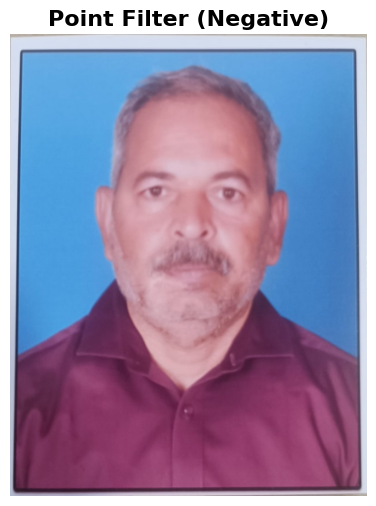


🧠 IMAGE FILTERING MENU
1. Point Filter (Negative)
2. Mean Filter
3. Median Filter
0. Exit
--------------------------------------------------
Enter choice (0-3): 0
👋 Exiting...

MAIN MENU
1. Geometric Transformations
2. Affine Transformations
3. Filters
0. Exit
--------------------------------------------------
Enter choice (0-3): 0
👋 Goodbye!


In [ ]:
uploaded = files.upload()
for filename in uploaded.keys():
    # Since Colab drops it in the current working directory (/content)
    full_path = os.path.abspath(filename)
transform = ImageTransformations(full_path)
transform.Main_menu()